First we have imported the liberies
then we have decrease the number of classes from 30 to 10 because we have limited resourses

In [1]:
import torch
from  torch.utils.data import Dataset , DataLoader
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from glob import glob 
import numpy as np
import os 


c:\Users\taher\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NUM_Classes = 10
CLASS_MAPPING = {
    0: 0,   # drivable area / road
    1: 1,   # sidewalk
    2: 2,   # person / pedestrian
    3: 3,   # two-wheeler (bicycle, motorcycle, scooter)
    4: 4,   # large vehicle (car, bus, truck)
    5: 5,   # animal
    6: 6,   # traffic sign
    7: 7,   # building
    8: 8,   # sky
    9: 9,   # background / other
}


class IDDDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        self.masks_files = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks_files[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # سطر الإنقاذ: أي قيمة بكسل >= 10 اجعلها 9 (Background)
        # هذا السطر يمنع الـ CUDA Error تماماً
        mask[mask >= 10] = 9 

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()

In [3]:
def load_image(path, mask=False):
    img = cv2.imread(path, -1) # `
    if not mask:
        img = img[...,::-1]
    else:
        if len(img.shape)>2:
            img = img[...,0:1]
    return img

In [4]:
import matplotlib.pyplot as plt
def show_sample(img, msk):
    
    plt.figure(figsize=(15,15))

    plt.subplot(1, 3, 1)
    plt.imshow(img);
    plt.title("Image")

    plt.subplot(1, 3, 2)
    plt.imshow(msk);
    plt.title("Mask")


    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(np.ma.masked_where(msk==0, msk), alpha=0.60, cmap='coolwarm_r')
    plt.title("Overlay")

    plt.tight_layout()
    plt.show()

## Image Shape: (1080, 1920, 3)


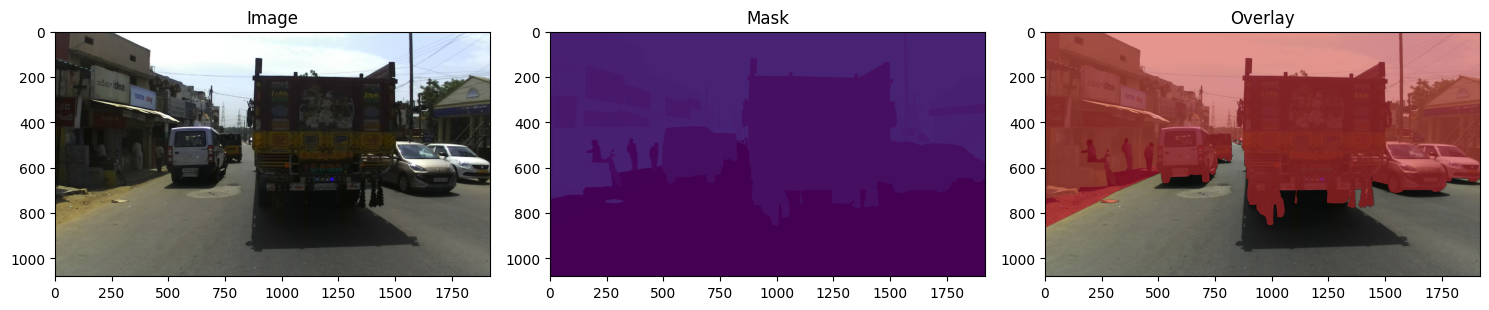

## Image Shape: (1080, 1920, 3)


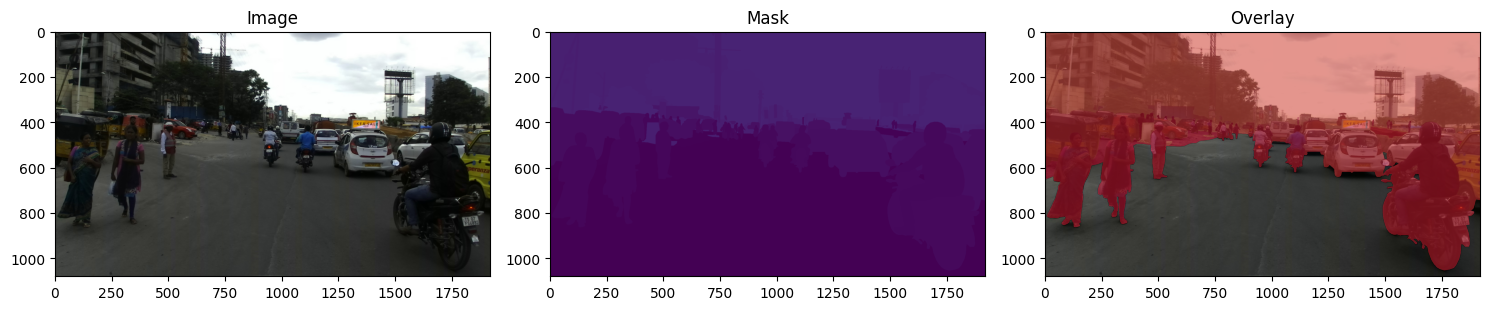

## Image Shape: (1080, 1920, 3)


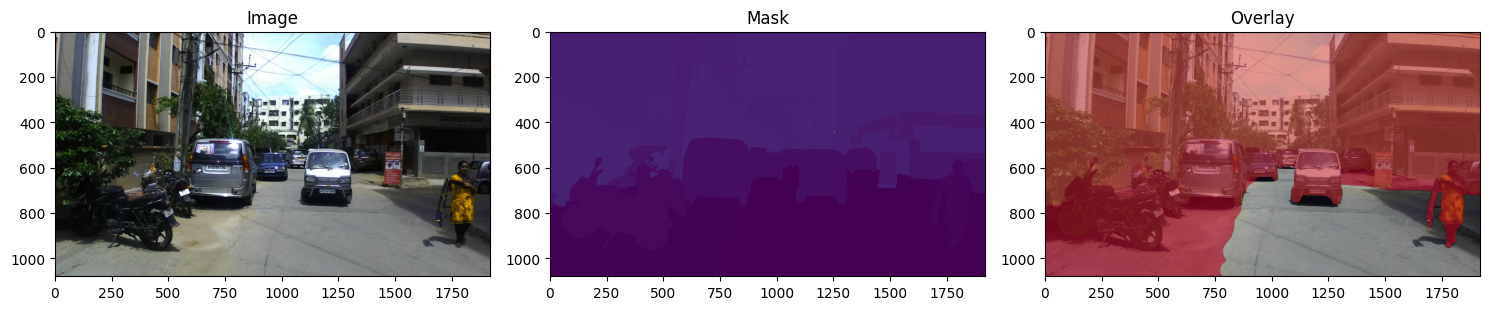

## Image Shape: (1080, 1920, 3)


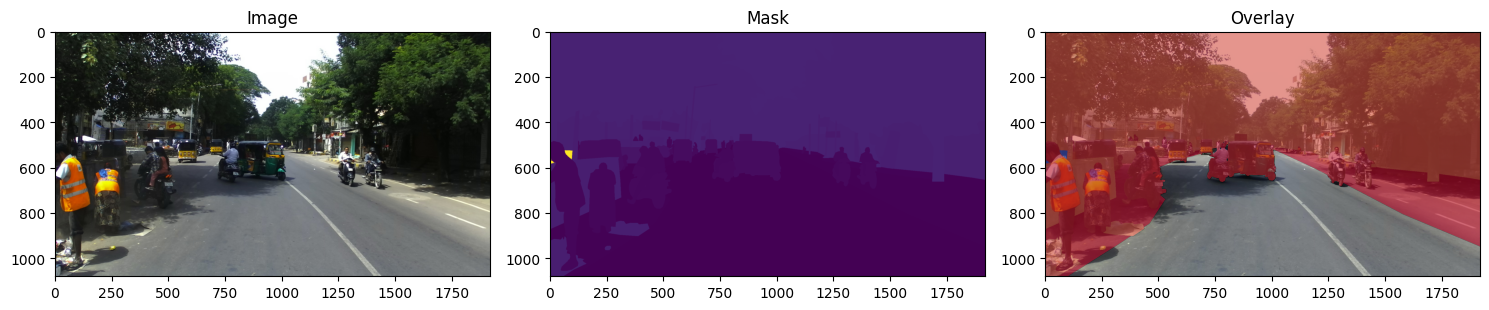

## Image Shape: (1080, 1920, 3)


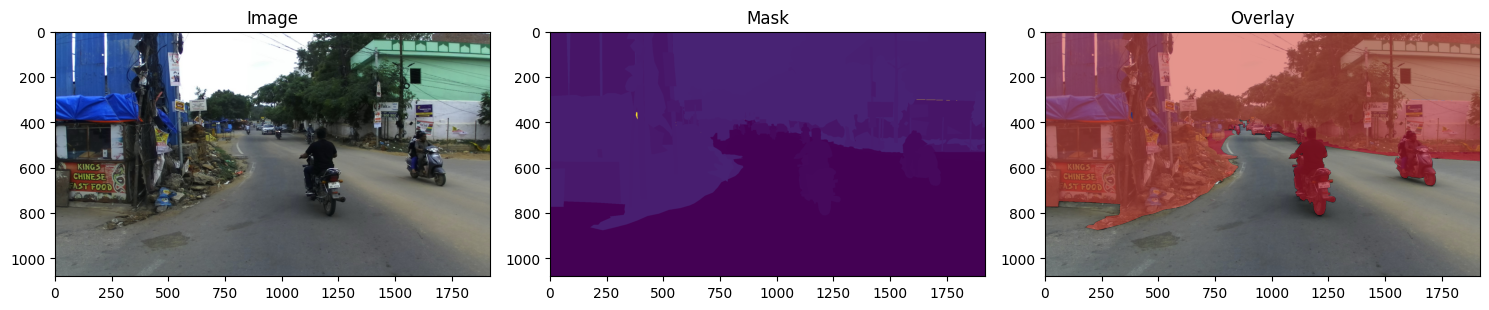

## Image Shape: (1080, 1920, 3)


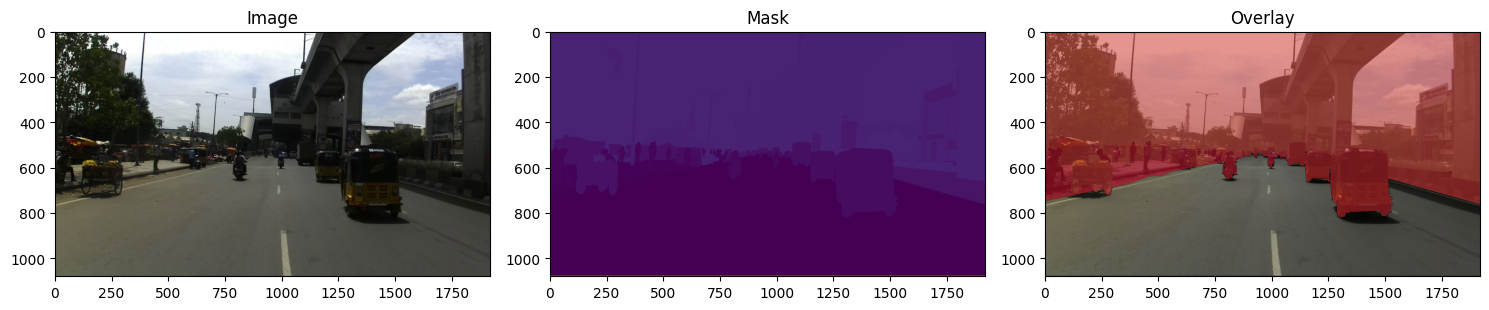

## Image Shape: (1080, 1920, 3)


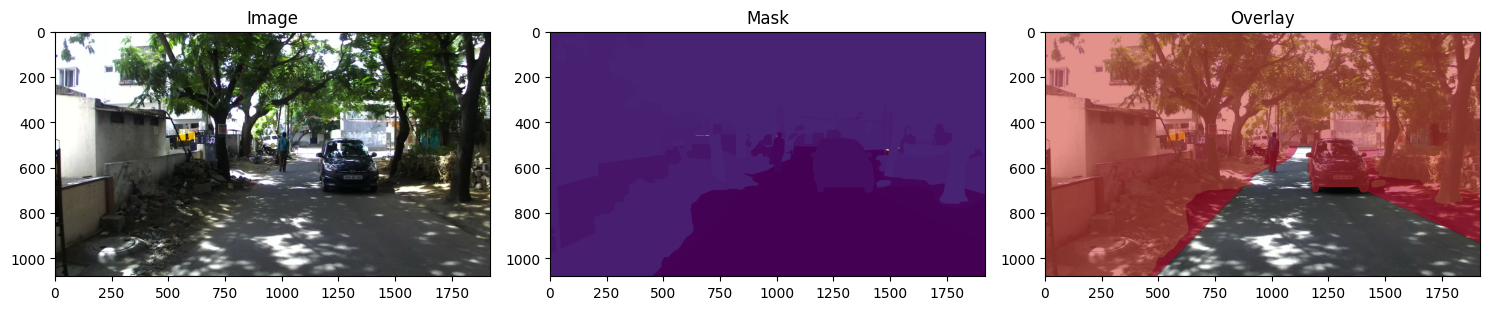

## Image Shape: (1080, 1920, 3)


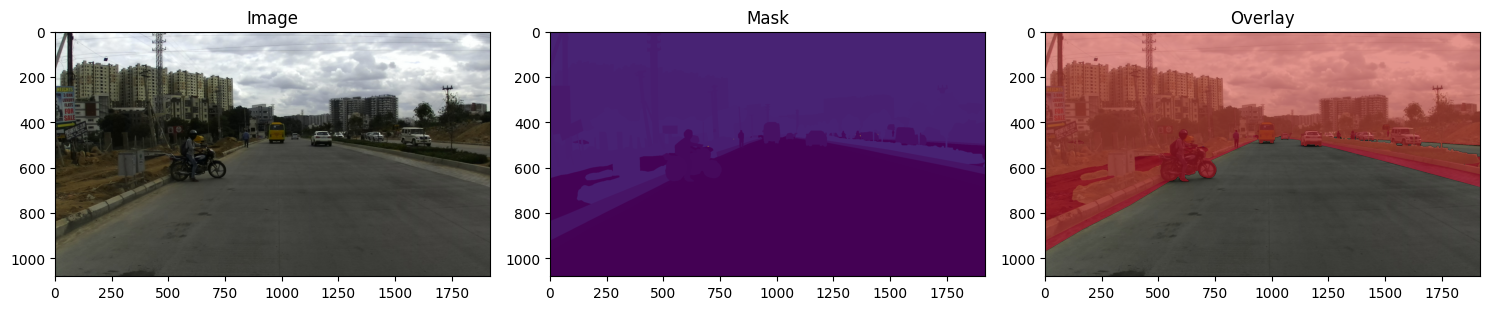

In [5]:
import pandas as pd
from glob import glob

sample_indices = range(0, 200, 25)


image_paths = sorted(glob('Data/dataset/IDD/train/images/*'))
label_paths = sorted(glob('Data/dataset/IDD/train/labels/*'))


df = pd.DataFrame(zip(image_paths, label_paths), columns=['image_path','mask_path'])

for i in sample_indices:
    row = df.iloc[i]

    img = load_image(row.image_path)
    print(f"## Image Shape: {img.shape}")

    msk = load_image(row.mask_path, 1)

    show_sample(img, msk)

In [6]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.RandomScale(scale_limit=(-0.5, 1.0), p=0.5),
    A.PadIfNeeded(min_height=512, min_width=512, border_mode=0, p=1.0),
    A.RandomCrop(512, 512),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])
# تعديل مجموعة التدريب
trainDataset = IDDDataset(
    image_dir='Data/dataset/IDD/train/images', 
    mask_dir='Data/dataset/IDD/train/labels', 
    transform=train_transform
)

# تعديل مجموعة التحقق
valDataset = IDDDataset(
    image_dir='Data/dataset/IDD/valid/images', 
    mask_dir='Data/dataset/IDD/valid/labels', 
    transform=val_transform
)
from torch.utils.data import DataLoader

# إعداد الـ DataLoaders
train_loader = DataLoader(
    trainDataset, 
    batch_size=8,      # يمكنك زيادته إلى 16 أو 32 إذا كان كرت الشاشة (GPU) قوياً
    shuffle=True,      # ضروري جداً في التدريب لعدم حفظ الترتيب
    num_workers=0,     # يسرع تحميل الصور باستخدام المعالج
    pin_memory=True    # يسرع نقل البيانات إلى كرت الشاشة
)

val_loader = DataLoader(
    valDataset, 
    batch_size=8, 
    shuffle=False,     # لا نحتاج للتبديل في مرحلة التحقق
    num_workers=0,
    pin_memory=True
)

# اختبار الـ DataLoader
images, masks = next(iter(train_loader))
print(f"Batch Images Shape: {images.shape}") # المتوقع: [8, 3, 512, 512]
print(f"Batch Masks Shape: {masks.shape}")   # المتوقع: [8, 512, 512]

Batch Images Shape: torch.Size([8, 3, 512, 512])
Batch Masks Shape: torch.Size([8, 512, 512])


In [7]:
import torch
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.DeepLabV3Plus(
    encoder_name="resnet50", 
    encoder_weights="ssl", 
    in_channels=3, 
    classes=10
)
weights_path = "model_v2_epoch_10.pth"
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)

print("✅ Pretrained weights loaded successfully!")
model = model.to(device)
model.eval()

print("✅ Model loaded with SSL weights successfully!")

✅ Pretrained weights loaded successfully!
✅ Model loaded with SSL weights successfully!


In [8]:
import torch.nn as nn
import torch.nn.functional as F

# حساب أوزان الفئات لمعالجة Class Imbalance
class_weights = torch.tensor([
    0.5,   # road       (كثيرة)
    1.0,   # sidewalk
    3.0,   # pedestrian (نادرة ← وزن أعلى)
    2.5,   # two-wheeler
    1.5,   # large vehicle
    4.0,   # animal     (نادرة جداً)
    3.0,   # traffic sign
    0.8,   # building
    0.5,   # sky
    1.0,   # background
]).to(device)

# تأكد أن لين الـ tensor يساوي عدد الـ classes في الموديل
criterion_ce = nn.CrossEntropyLoss(weight=class_weights)
criterion_dice = smp.losses.DiceLoss(mode='multiclass')

def combined_loss(pred, target):
    # حساب الخسارة الأولى (تركز على دقة التصنيف)
    loss_ce = criterion_ce(pred, target)
    
    # حساب الخسارة الثانية (تركز على تداخل الأجسام)
    loss_dice = criterion_dice(pred, target)
    
    # دمج الاثنين بنسب متساوية
    return 0.5 * loss_ce + 0.5 * loss_dice

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.PolynomialLR(
    optimizer, total_iters=50, power=0.9
)

In [10]:
def compute_miou(preds, targets, num_classes=NUM_Classes):
    preds   = torch.argmax(preds, dim=1)  # (B, H, W)
    iou_per_class = []

    for cls in range(num_classes):
        pred_cls   = (preds == cls)
        target_cls = (targets == cls)
        intersection = (pred_cls & target_cls).sum().float()
        union        = (pred_cls | target_cls).sum().float()

        if union == 0:
            continue   # تجاهل الفئات الغائبة
        iou_per_class.append((intersection / union).item())

    return sum(iou_per_class) / len(iou_per_class) if iou_per_class else 0.0

In [11]:
from tqdm import tqdm

# تحويل تلقائي للـ CPU إذا فشل الكارت (لتجنب الانهيار)
try:
    test_tensor = torch.zeros(1).to(device)
    use_amp = False
    print("🚀 GPU is ready and compatible!")
except:
    print("⚠️ GPU Incompatible. Switching to CPU to keep moving...")
    device = torch.device("cpu")
    model.to(device)
    use_amp = False

# الإعدادات المحدثة (لتجنب التحذيرات)
scaler = torch.amp.GradScaler('cuda') # خاص بكروت NVIDIA الحديثة
epochs = 30 
for epoch in range(epochs):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)

        # استخدام تقنية الـ Auto-cast لزيادة السرعة
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = combined_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # حفظ النموذج بعد كل دورة
torch.save(model.state_dict(), f"model_v2_epoch_{epoch+1}.pth")

🚀 GPU is ready and compatible!


Epoch 30: 100%|██████████| 746/746 [02:52<00:00,  4.32it/s, loss=0.1173]


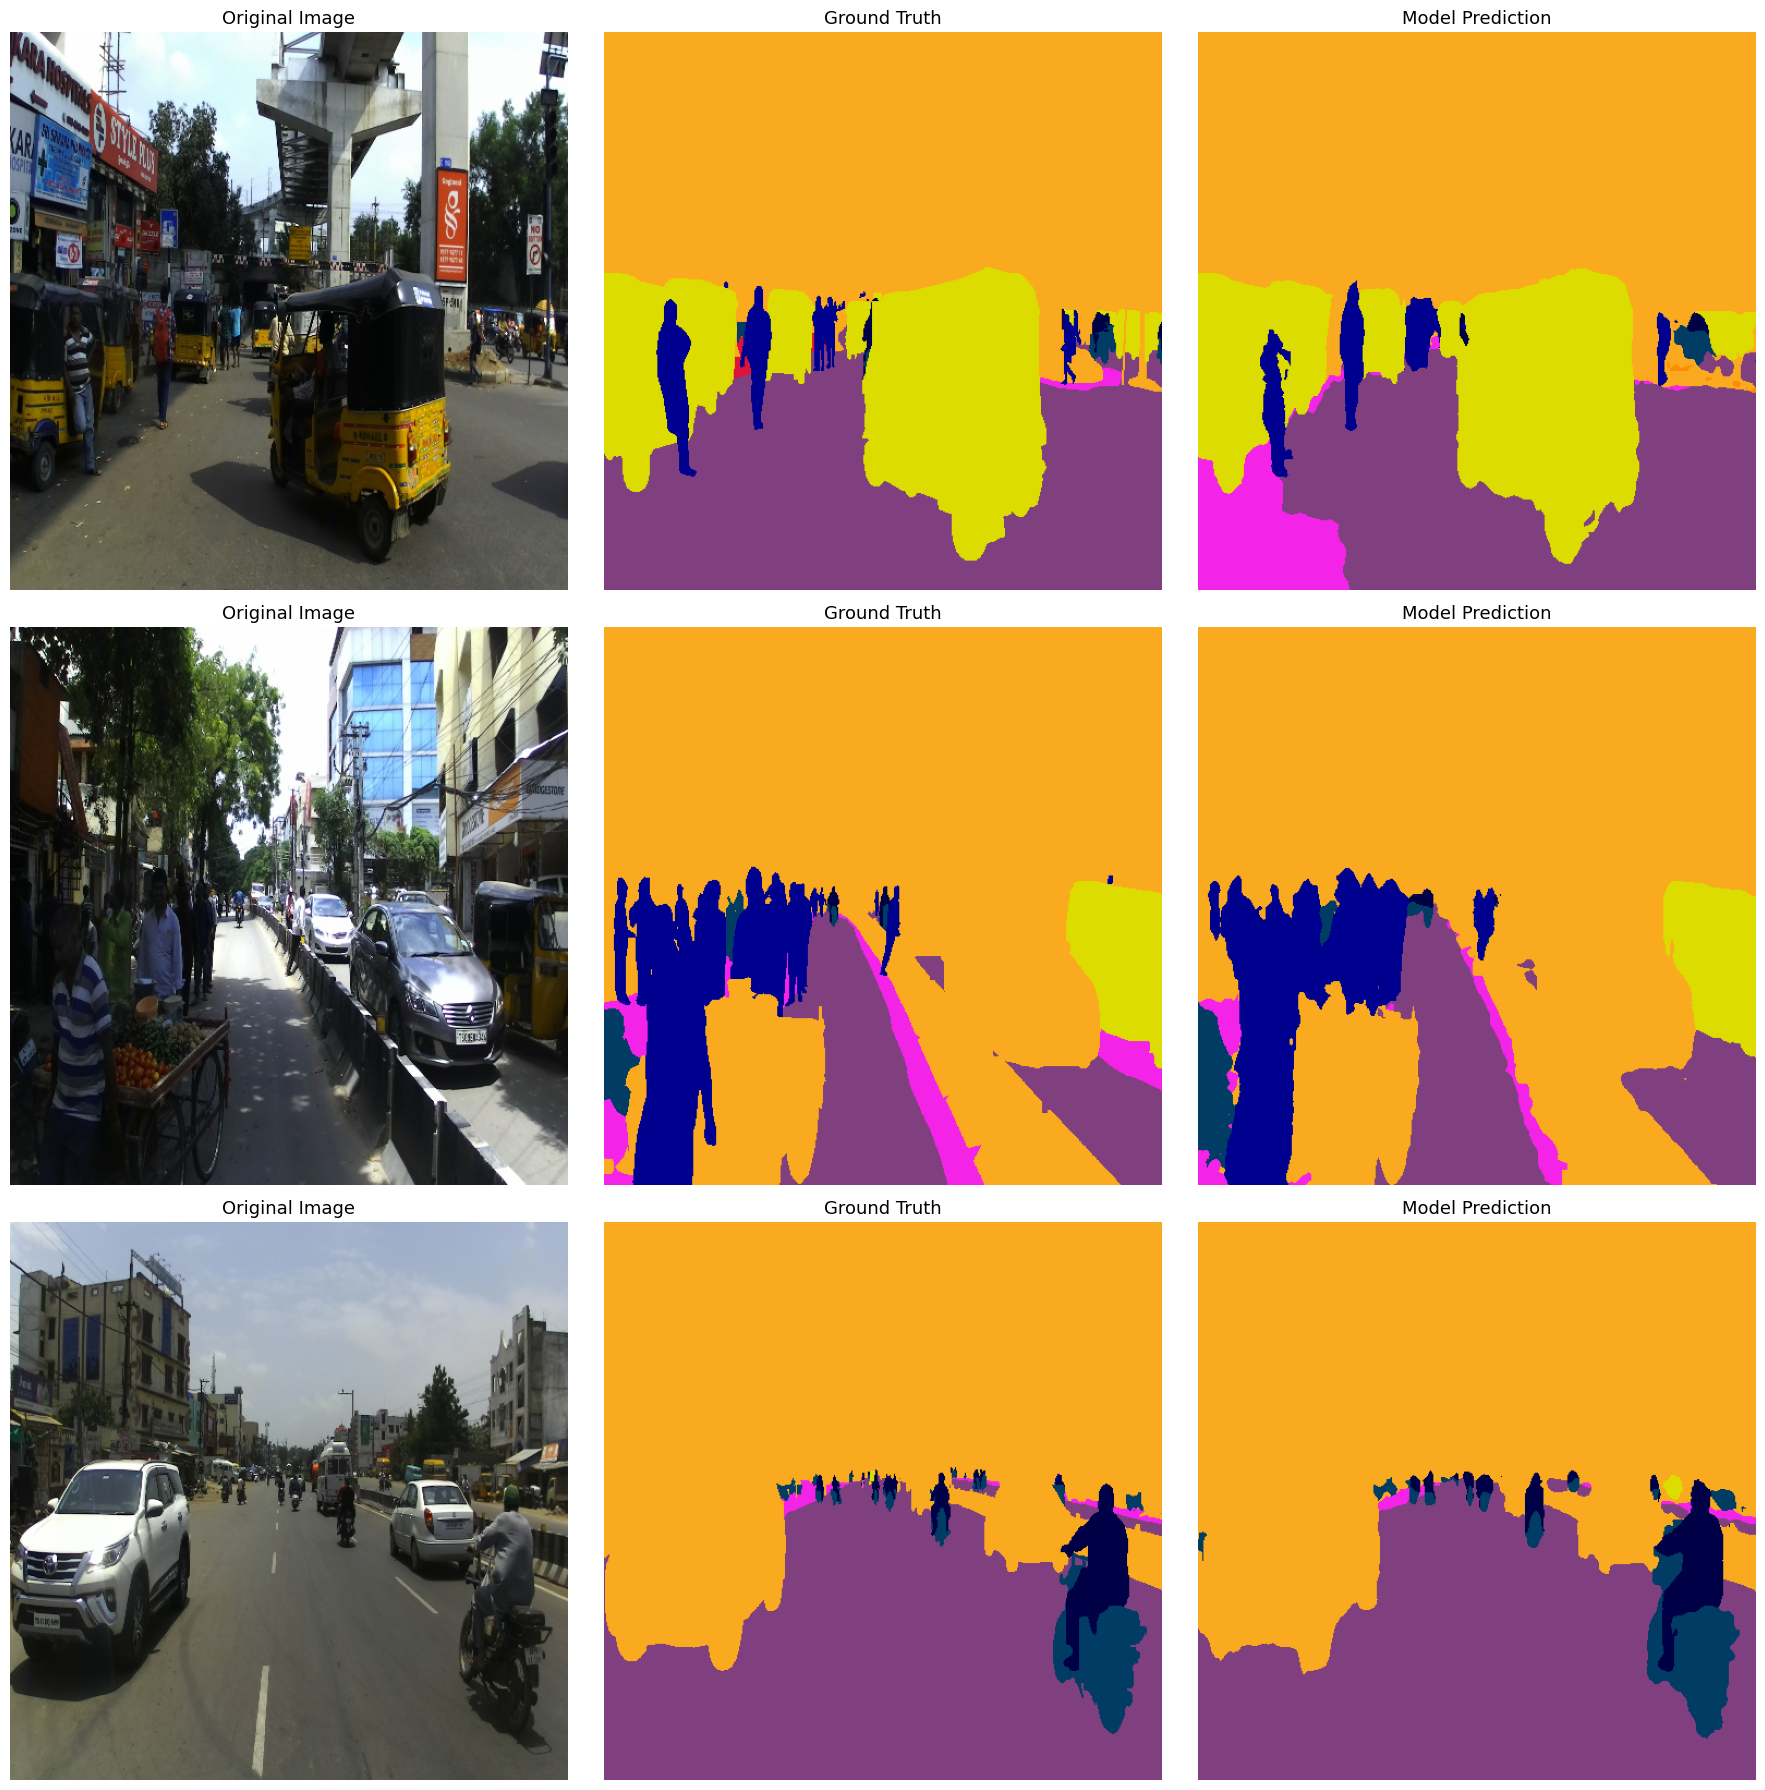

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import numpy as np

# ألوان واضحة لكل كلاس
CLASS_COLORS = np.array([
    [128, 64, 128],   # 0  - road (بنفسجي)
    [244, 35, 232],   # 1  - sidewalk (وردي)
    [220, 20, 60],    # 2  - pedestrian (أحمر)
    [255, 140, 0],    # 3  - two-wheeler (برتقالي)
    [0, 0, 142],      # 4  - car (أزرق غامق)
    [0, 0, 70],       # 5  - truck (أزرق أغمق)
    [0, 60, 100],     # 6  - bus (أزرق)
    [255, 105, 180],  # 7  - animal (وردي فاتح)
    [220, 220, 0],    # 8  - traffic sign (أصفر)
    [250, 170, 30],   # 9  - traffic light (أصفر فاتح)
    [70, 70, 70],     # 10 - building (رمادي)
    [100, 40, 40],    # 11 - bridge (بني)
    [190, 153, 153],  # 12 - fence (وردي باهت)
    [180, 165, 180],  # 13 - guard rail (رمادي فاتح)
    [90, 120, 150],   # 14 - wall (أزرق رمادي)
    [107, 142, 35],   # 15 - vegetation (أخضر)
    [70, 130, 180],   # 16 - sky (سماوي)
    [255, 0, 0],      # 17 - person (أحمر فاقع)
    [0, 0, 230],      # 18 - rider (أزرق فاقع)
    [119, 11, 32],    # 19 - motorcycle (أحمر غامق)
    [0, 60, 0],       # 20 - bicycle (أخضر غامق)
    [0, 200, 0],      # 21 - autorickshaw (أخضر فاتح)
    [111, 74, 0],     # 22 - misc (بني)
    [81, 0, 81],      # 23 - unlabeled (بنفسجي غامق)
    [250, 170, 160],  # 24 - ego vehicle (سلموني)
    [230, 150, 140],  # 25 - out of roi (وردي باهت)
], dtype=np.uint8)

def decode_mask(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in enumerate(CLASS_COLORS):
        color_mask[mask == class_id] = color
    return color_mask

def visualize_prediction(model, dataset, device, num_images=3):
    model.eval()
    fig, ax = plt.subplots(num_images, 3, figsize=(18, num_images * 6))

    for i in range(num_images):
        image, mask = dataset[np.random.randint(0, len(dataset))]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        # الصورة الأصلية
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = (img_display * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        img_display = np.clip(img_display, 0, 1)

        ax[i, 0].imshow(img_display)
        ax[i, 0].set_title("Original Image", fontsize=13)
        ax[i, 0].axis('off')

        # القناع الحقيقي بألوان واضحة
        ax[i, 1].imshow(decode_mask(mask.cpu().numpy()))
        ax[i, 1].set_title("Ground Truth", fontsize=13)
        ax[i, 1].axis('off')

        # توقع الموديل بألوان واضحة
        ax[i, 2].imshow(decode_mask(prediction))
        ax[i, 2].set_title("Model Prediction", fontsize=13)
        ax[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_prediction(model, valDataset, device)